Linear & Polynomial Regression
Dataset: Stars Luminosity

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures,StandardScaler
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.pipeline import Pipeline


Download from: https://www.kaggle.com/datasets/deepu1109/star-dataset

File name: 6 class csv.csv

In [ ]:
df=pd.read_csv("/content/6 class csv.csv")

In [ ]:
print(df.head())

   Temperature (K)  Luminosity(L/Lo)  Radius(R/Ro)  Absolute magnitude(Mv)  \
0             3068          0.002400        0.1700                   16.12   
1             3042          0.000500        0.1542                   16.60   
2             2600          0.000300        0.1020                   18.70   
3             2800          0.000200        0.1600                   16.65   
4             1939          0.000138        0.1030                   20.06   

   Star type Star color Spectral Class  
0          0        Red              M  
1          0        Red              M  
2          0        Red              M  
3          0        Red              M  
4          0        Red              M  


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Temperature (K)         240 non-null    int64  
 1   Luminosity(L/Lo)        240 non-null    float64
 2   Radius(R/Ro)            240 non-null    float64
 3   Absolute magnitude(Mv)  240 non-null    float64
 4   Star type               240 non-null    int64  
 5   Star color              240 non-null    object 
 6   Spectral Class          240 non-null    object 
dtypes: float64(3), int64(2), object(2)
memory usage: 13.3+ KB


In [ ]:
df.describe()

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type
count,240.000000,240.000000,240.000000,240.000000,240.000000
mean,10497.462500,107188.361635,237.157781,4.382396,2.500000
std,9552.425037,179432.244940,517.155763,10.532512,1.711394
min,1939.000000,0.000080,0.008400,-11.920000,0.000000
25%,3344.250000,0.000865,0.102750,-6.232500,1.000000
50%,5776.000000,0.070500,0.762500,8.313000,2.500000
75%,15055.500000,198050.000000,42.750000,13.697500,4.000000
max,40000.000000,849420.000000,1948.500000,20.060000,5.000000


Luminosity varies enormously — from tiny dwarf stars to supergiants


Text(0.5, 0, 'Luminosity')

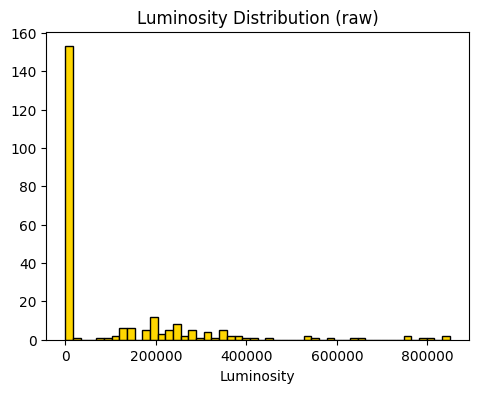

In [ ]:
plt.figure(figsize=(12,4))
plt.subplot(1, 2, 1)
plt.hist(df['Luminosity(L/Lo)'], bins=50, color='gold', edgecolor='k')
plt.title('Luminosity Distribution (raw)')
plt.xlabel('Luminosity')

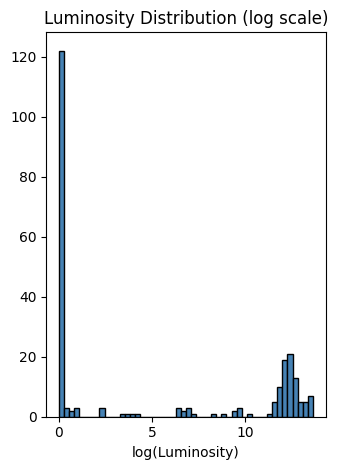

In [ ]:
plt.subplot(1, 2, 2)
plt.hist(np.log1p(df['Luminosity(L/Lo)']), bins=50, color='steelblue', edgecolor='k')
plt.title('Luminosity Distribution (log scale)')
plt.xlabel('log(Luminosity)')
plt.tight_layout()
plt.show()


We use Temperature, Radius, and Absolute Magnitude as inputs

Target is log(Luminosity) — log transform tames the huge range

In [ ]:
X = df[['Temperature (K)', 'Radius(R/Ro)', 'Absolute magnitude(Mv)']].values
y = np.log1p(df['Luminosity(L/Lo)'].values)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


Temperature is in thousands, radius in single digits — scale

fit scaler on train only, then transform both


In [ ]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

In [ ]:
lin_model = LinearRegression()
lin_model.fit(X_train_s, y_train)

y_pred_lin = lin_model.predict(X_test_s)

rmse_lin = np.sqrt(mean_squared_error(y_test, y_pred_lin))
r2_lin   = r2_score(y_test, y_pred_lin)

print("═══ LINEAR REGRESSION ═══")
print(f"RMSE : {rmse_lin:.4f}")
print(f"R²   : {r2_lin:.4f}")
print(f"Coefficients: {dict(zip(['Temperature','Radius','Abs Magnitude'], lin_model.coef_.round(3)))}")


═══ LINEAR REGRESSION ═══
RMSE : 1.8350
R²   : 0.9083
Coefficients: {'Temperature': np.float64(0.335), 'Radius': np.float64(0.101), 'Abs Magnitude': np.float64(-5.296)}


Pipeline chains steps — it scales, then adds polynomial features,

In [ ]:
poly_model = Pipeline([
    ('poly',   PolynomialFeatures(degree=2, include_bias=False)),
    ('linear', LinearRegression())
])

poly_model.fit(X_train_s, y_train)
y_pred_poly = poly_model.predict(X_test_s)

rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))
r2_poly   = r2_score(y_test, y_pred_poly)

print("\n═══ POLYNOMIAL REGRESSION (degree=2) ═══")
print(f"RMSE : {rmse_poly:.4f}")
print(f"R²   : {r2_poly:.4f}")


═══ POLYNOMIAL REGRESSION (degree=2) ═══
RMSE : 0.7469
R²   : 0.9848


 COMPARE degrees 1 through 6
 This is the bias-variance tradeoff in action — watch what happens

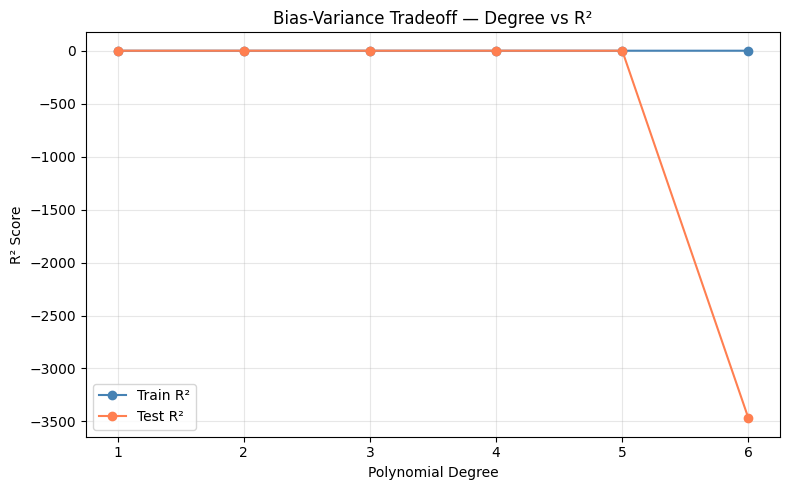

In [ ]:
degrees     = range(1, 7)
train_r2s   = []
test_r2s    = []

for d in degrees:
    pipe = Pipeline([
        ('poly',   PolynomialFeatures(degree=d, include_bias=False)),
        ('linear', LinearRegression())
    ])
    pipe.fit(X_train_s, y_train)
    train_r2s.append(r2_score(y_train, pipe.predict(X_train_s)))
    test_r2s.append(r2_score(y_test,  pipe.predict(X_test_s)))

plt.figure(figsize=(8, 5))
plt.plot(degrees, train_r2s, 'o-', label='Train R²', color='steelblue')
plt.plot(degrees, test_r2s,  'o-', label='Test R²',  color='coral')
plt.xlabel('Polynomial Degree')
plt.ylabel('R² Score')
plt.title('Bias-Variance Tradeoff — Degree vs R²')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Train R² keeps climbing with degree (model memorizes more)

Test R² peaks somewhere then drops or flattens (overfitting kicks in)

The best degree = where test R² is highest



In [ ]:
for d, tr, te in zip(degrees, train_r2s, test_r2s):
    print(f"Degree {d} → Train R²: {tr:.4f} | Test R²: {te:.4f} | Gap: {tr-te:.4f}")

The sweet spot is whichever row has the highest Test R² and the smallest gap.

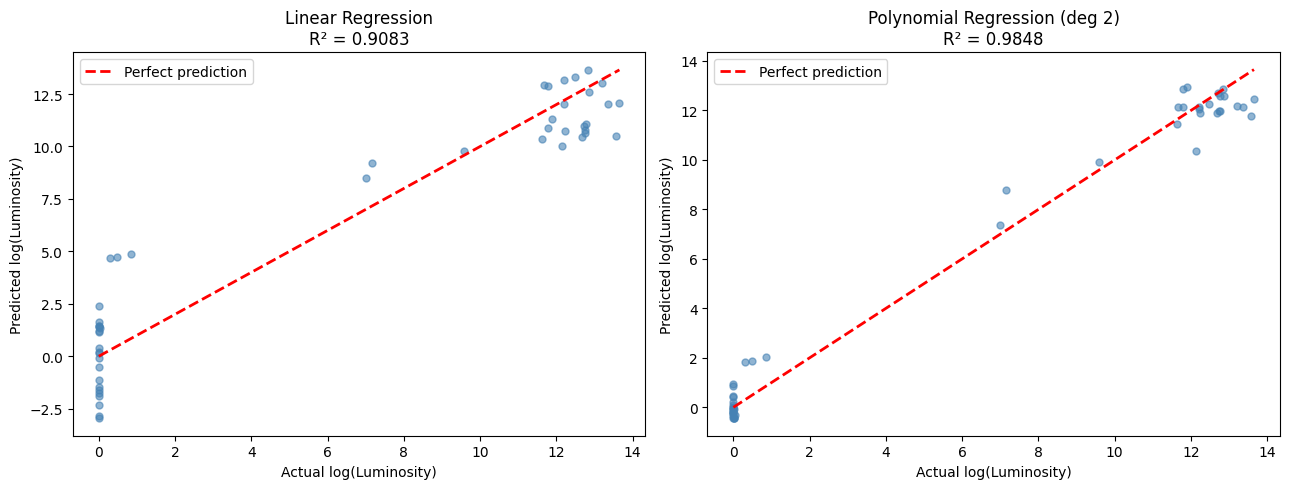

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, preds, title, r2 in zip(
    axes,
    [y_pred_lin, y_pred_poly],
    ['Linear Regression', 'Polynomial Regression (deg 2)'],
    [r2_lin, r2_poly]
):
    ax.scatter(y_test, preds, alpha=0.6, s=25, color='steelblue')
    mn, mx = y_test.min(), y_test.max()
    ax.plot([mn, mx], [mn, mx], 'r--', lw=2, label='Perfect prediction')
    ax.set_xlabel('Actual log(Luminosity)')
    ax.set_ylabel('Predicted log(Luminosity)')
    ax.set_title(f'{title}\nR² = {r2:.4f}')
    ax.legend()

plt.tight_layout()
plt.show()

 the polynomial plot has dots tighter around the line than the linear one, polynomial is the better fit.


═══ SCRATCH MODEL ═══
R²: 0.9083


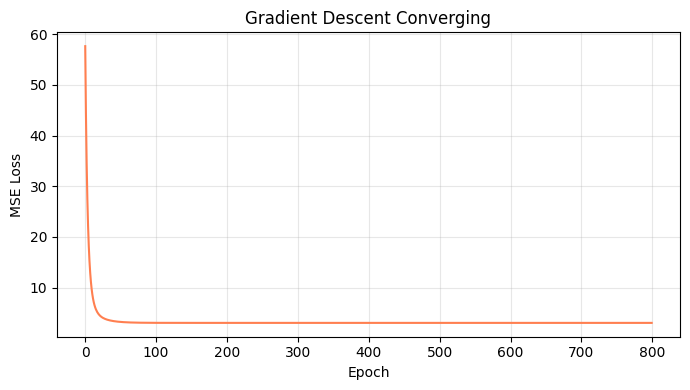

In [ ]:
class LinearRegressionScratch:
    def __init__(self, lr=0.01, epochs=1000):
        self.lr     = lr
        self.epochs = epochs
        self.losses = []

    def fit(self, X, y):
        n, p      = X.shape
        self.beta = np.zeros(p + 1)          # β₀, β₁ ... βₙ
        X_b       = np.c_[np.ones(n), X]    # add bias column of 1s

        for epoch in range(self.epochs):
            y_hat = X_b @ self.beta          # ŷ = Xβ
            error = y_hat - y                # residuals
            grad  = (2/n) * X_b.T @ error   # ∂J/∂β
            self.beta -= self.lr * grad      # gradient descent step
            loss = np.mean(error**2)         # MSE
            self.losses.append(loss)

    def predict(self, X):
        return np.c_[np.ones(len(X)), X] @ self.beta

# Train scratch model
scratch = LinearRegressionScratch(lr=0.05, epochs=800)
scratch.fit(X_train_s, y_train)

y_pred_scratch = scratch.predict(X_test_s)
print(f"\n═══ SCRATCH MODEL ═══")
print(f"R²: {r2_score(y_test, y_pred_scratch):.4f}")

# Plot loss curve — watch gradient descent converge
plt.figure(figsize=(7, 4))
plt.plot(scratch.losses, color='coral')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Gradient Descent Converging')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

800 rounds (epochs)
curve drops steeply at first, then flattens — this means the model is converging
the model has learned as much as it can